DATA LOADING

In [4]:
import pandas as pd

df = pd.read_excel("OnlineRetail.xlsx")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


DATA CLEANING

In [5]:
df.dropna(inplace=True)

In [6]:
df.drop_duplicates(inplace=True)

FEATURE ENGINEERING

In [7]:
df['Revenue'] = df['Quantity'] * df['Price']

EDA (Exploratory Data Analysis)

In [8]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID,Revenue
count,410763.000000,410763,410763.000000,410763.000000,410763.000000
mean,12.923735,2010-06-30 19:56:14.853674752,3.908358,15353.621857,20.242465
min,-9360.000000,2009-12-01 07:45:00,0.000000,12346.000000,-25111.090000
25%,2.000000,2010-03-26 09:46:00,1.250000,13979.000000,4.500000
50%,5.000000,2010-07-08 15:09:00,1.950000,15311.000000,11.800000
75%,12.000000,2010-10-14 12:32:00,3.750000,16797.000000,19.500000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000,15818.400000
std,102.039550,NaN,71.714794,1681.657665,100.710825


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 410763 entries, 0 to 525460
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      410763 non-null  object        
 1   StockCode    410763 non-null  object        
 2   Description  410763 non-null  object        
 3   Quantity     410763 non-null  int64         
 4   InvoiceDate  410763 non-null  datetime64[ns]
 5   Price        410763 non-null  float64       
 6   Customer ID  410763 non-null  float64       
 7   Country      410763 non-null  object        
 8   Revenue      410763 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 31.3+ MB


In [10]:
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
Revenue        0
dtype: int64

VISUALIZATIONS

[]

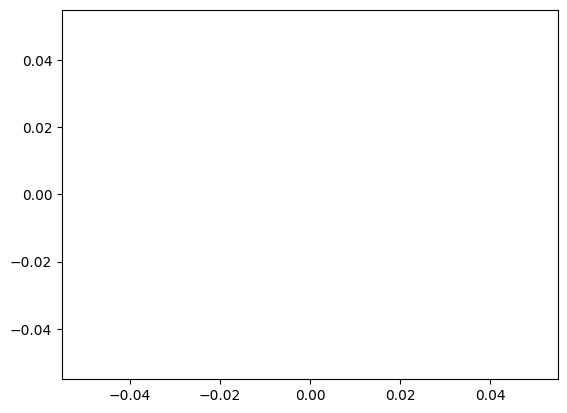

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.barplot()
plt.plot()

CUSTOMER ANALYSIS

In [14]:
df.groupby('Customer ID')

TOP PRODUCTS

In [15]:
top_products = (
    df.groupby('Description')['Revenue']
    .sum()
)

FORECASTING

In [18]:
import pandas as pd

# Load Dataset
df = pd.read_excel("OnlineRetail.xlsx")

# Convert Date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create Month Column
df['Month'] = df['InvoiceDate'].dt.month

# Create Revenue Column
df['Revenue'] = df['Quantity'] * df['Price']

# Monthly Revenue
forecast_data = (
    df.groupby('Month')['Revenue']
    .sum()
    .reset_index()
)

# Forecasting
forecast_data['Forecast'] = (
    forecast_data['Revenue']
    .rolling(2)
    .mean()
)

forecast_data

,Month,Revenue,Forecast
0,1,624032.892,NaN
1,2,533091.426,5.785622e+05
2,3,765848.761,6.494701e+05
3,4,590580.432,6.782146e+05
4,5,615322.830,6.029516e+05
5,6,679786.610,6.475547e+05
6,7,575236.360,6.275115e+05
7,8,656776.340,6.160063e+05
8,9,853650.431,7.552134e+05
9,10,1045168.350,9.494094e+05
